# 00 — ติดตั้งเครื่องมือ + ทัวร์ข้อมูล

ยินดีต้อนรับสู่บทแรกครับ 🎉 บทนี้ยังไม่มี Machine Learning เลยสักบรรทัด —
เป้าหมายเดียวคือ **"เห็นธุรกิจตัวเองใน DataFrame ให้ได้ก่อน"**
เพราะโมเดลที่ดีเริ่มจากคนที่รู้จักข้อมูลตัวเองดีที่สุด ซึ่งก็คือคุณนั่นแหละ

**จบบทนี้คุณจะ:**
1. รัน Jupyter notebook ของโปรเจกต์นี้ได้เอง (venv + โหมดข้อมูล SAMPLE/REAL)
2. รู้จัก 3 แหล่งข้อมูลของเรา — Sheets ปี 68 / Supabase ปี 69 / snapshot จาก PM webapp
3. ปัดฝุ่น pandas: `read_csv` · `head/info/describe` · filtering · `groupby`
4. ตอบคำถามธุรกิจจริง 3 ข้อจากข้อมูล แล้ววาดกราฟแรกของหลักสูตร

ใช้เวลาประมาณ 60 นาที ค่อยๆ ไปครับ ไม่ต้องรีบ

In [1]:
import sys; sys.path.insert(0, "..")
import pandas as pd
from src import checks, churn_utils, contracts
from src.config import DATA_DIR, IS_SAMPLE
plt = churn_utils.plot_style()
print("โหมดข้อมูล:", "SAMPLE (ข้อมูลจำลอง)" if IS_SAMPLE else f"REAL ({DATA_DIR})")

โหมดข้อมูล: SAMPLE (ข้อมูลจำลอง)


## หลักสูตรนี้พาไปไหน — แผนที่ 9 บท

ปลายทางของเราชัดมาก: **risk report รายเดือน** — ตารางที่บอกว่า
"เดือนหน้า น้องคนไหนเสี่ยงหลุดคอร์ส (ยกเลิก subscription) มากที่สุด"
เรียงลำดับให้ mentor หยิบไปโทรหาผู้ปกครองได้เลย ไม่ต้องเดาเอง

| บท | ทำอะไร | ได้อะไร |
|----|--------|---------|
| **00** | ติดตั้งเครื่องมือ + ทัวร์ข้อมูล (บทนี้) | เห็นธุรกิจใน DataFrame |
| 01 | นิยาม churn ให้เป๊ะ + สร้าง label | ตาราง label รายเดือน |
| 02 | ต่อท่อข้อมูลจริง (Sheets 68 + Supabase 69) | data/processed พร้อมใช้ |
| 03 | EDA — ส่องพฤติกรรมเด็กก่อนหายไป | insight + สมมติฐาน |
| 04 | สร้าง features แบบไม่ leak อนาคต | ตาราง features รายเดือน |
| 05 | เทรนโมเดลแรก | โมเดลทำนาย churn |
| 06 | วัดผลแบบธุรกิจ (precision@k vs ระบบ tier เดิม) | รู้ว่าโมเดลชนะของเดิมจริงไหม |
| 07 | อธิบายโมเดล — ทำไมน้องคนนี้เสี่ยง | เหตุผลรายคน ให้ mentor ใช้คุย |
| 08 | ประกอบร่าง — risk report รายเดือนอัตโนมัติ | ระบบที่รันเองได้ทุกเดือน |

ทุกบทเป็น notebook แบบนี้: อธิบายสั้นๆ → ตัวอย่าง → ให้คุณลงมือทำ →
มีตัวตรวจ (`checks.check`) บอกทันทีว่าผ่านหรือยัง เหมือนมีผมนั่งข้างๆ คอยเช็คให้

## เปิดเครื่องมือยังไง (ทำครั้งเดียว จำไว้ใช้ทุกบท)

เปิด Terminal แล้วพิมพ์ 3 บรรทัดนี้:

```bash
cd "~/Desktop/Claude code/ml-churn"
source venv/bin/activate
jupyter lab
```

เบราว์เซอร์จะเด้งขึ้นมา → เข้าโฟลเดอร์ `notebooks/` → เปิดไฟล์บทที่ต้องการ
รันทีละ cell ด้วย `Shift+Enter` จากบนลงล่าง (ถ้าเครื่องงงๆ ให้ `Kernel → Restart` แล้วรันใหม่จากบนสุด)

### โหมดข้อมูล: SAMPLE vs REAL

| โหมด | ใช้ข้อมูล | เมื่อไหร่ |
|------|-----------|----------|
| **SAMPLE** (ค่าเริ่มต้น) | `data/sample/` — ข้อมูลจำลอง 310 คน หน้าตาเหมือนของจริงเป๊ะ | เรียนทุกบท ปลอดภัย ไม่กระทบข้อมูลจริง |
| **REAL** | `data/processed/` — ข้อมูลจริงหลังทำบท 02 | ตอนใช้งานจริง |

สลับโหมดด้วย environment variable ก่อนเปิด jupyter:

```bash
ML_CHURN_DATA=real jupyter lab   # โหมดข้อมูลจริง (ยังไม่ต้องใช้ตอนนี้)
```

ตอนนี้เราอยู่โหมด SAMPLE — ดูได้จาก cell แรกที่รันไปเมื่อกี้ พิมพ์ว่า `โหมดข้อมูล: SAMPLE` ✅
ตัวเลขทุกตัวในบทนี้เลยเป็น "ตัวเลขจำลอง" นะครับ อย่าเพิ่งเอาไปตัดสินใจธุรกิจ 😄

## ข้อมูลของเรามาจาก 3 ที่

| แหล่ง | ซีซัน | หน้าตา | ใครดึง |
|-------|-------|--------|--------|
| **Google Sheets** | ปี 2568 (จบแล้ว) | ไฟล์ export ที่คุณวางใน `data/raw/2568/` | คุณ (บท 02) |
| **Supabase (Eduwise)** | ปี 2569 (กำลังสอน) | ดึงตรงจากฐานข้อมูลด้วย `src/eduwise_extract.py` | สคริปต์ (read-only) |
| **PM webapp snapshot** | รายสัปดาห์ | `pm-webapp/tasks.db` — รายงานที่ mentor ใช้ส่ง LINE ทุกสัปดาห์ | มีอยู่แล้ว |

ข่าวดีคือ: ไม่ว่ามาจากไหน สุดท้ายทุกอย่างถูกแปลงให้อยู่ใน **schema เดียวกัน**
(กติกาเขียนไว้ใน `src/contracts.py` — บทหลังๆ จะได้ใช้บ่อย)
วันนี้เราซ้อมมือกับชุด sample ที่หน้าตาเหมือนของจริงทุกกระเบียดนิ้วก่อน
แล้วท้ายบทจะแอบเปิด snapshot ของจริงให้ดูว่า "เหมือนกันจริงๆ นะ"

> ⚠️ **กับดัก!** ไฟล์ทุกไฟล์มีข้อมูล **2 ซีซันปนกัน** (คอลัมน์ `year` = 2568 กับ 2569)
> ลืมกรอง `year` เมื่อไหร่ ตัวเลขจะ "ปนปี" ทันที — เจอตัวเลขแปลกๆ ให้สงสัยข้อนี้ก่อนเลย

## ปัดฝุ่น pandas 5 นาที — เปิดทะเบียนนักเรียนกัน

ไฟล์แรกที่ควรรู้จัก: `students.csv` — **1 แถว = นักเรียน 1 คนใน 1 ซีซัน**
มีชั้นเรียน โรงเรียนเป้าหมาย เรียนสดหรือดูเทป สมัครช้าแค่ไหน ลงกี่วิชา

ท่าประจำเวลาเจอไฟล์ใหม่ (ใช้ได้ทั้งชีวิต): **โหลด → `head()` → `info()` → `describe()`**

In [2]:
# read_csv = โหลดไฟล์ · parse_dates = แปลงคอลัมน์วันที่จากข้อความให้เป็นวันที่จริง
students = pd.read_csv(DATA_DIR / "students.csv", parse_dates=["signup_date"])

print("ขนาดตาราง (แถว, คอลัมน์):", students.shape)
students.head(3)   # แอบดู 3 แถวแรก

ขนาดตาราง (แถว, คอลัมน์): (310, 14)


,student_key,year,student_code,display_name,grade,school,target_school,live_or_replay,old_new,signup_date,signup_lateness,n_subjects,subject_ids,same_person_key
0,2568-1001,2568,1001,น้องพลอย 1001,ม.2,สาธิตปทุมวัน,TU,สด,old,2025-06-13,3,4,1;4;5;6,NaN
1,2568-1002,2568,1002,น้องอิง 1002,ม.1,บดินทรเดชา,MWIT,สด,new,2025-03-20,0,4,1;4;5;6,NaN
2,2568-1003,2568,1003,น้องพลอย 1003,ม.3,อื่นๆ,MWIT,สด,new,2025-03-03,0,4,1;4;5;6,NaN


In [3]:
# info() = เช็คชนิดข้อมูลแต่ละคอลัมน์ + มีค่าว่างไหม — ท่าตรวจสุขภาพไฟล์
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   student_key      310 non-null    str           
 1   year             310 non-null    int64         
 2   student_code     310 non-null    int64         
 3   display_name     310 non-null    str           
 4   grade            310 non-null    str           
 5   school           310 non-null    str           
 6   target_school    310 non-null    str           
 7   live_or_replay   310 non-null    str           
 8   old_new          310 non-null    str           
 9   signup_date      310 non-null    datetime64[us]
 10  signup_lateness  310 non-null    int64         
 11  n_subjects       310 non-null    int64         
 12  subject_ids      310 non-null    str           
 13  same_person_key  0 non-null      float64       
dtypes: datetime64[us](1), float64(1), int64(4), str(8)
me

In [4]:
# filtering: ใส่เงื่อนไขใน [ ] — เช่น เด็ก ม.3 (ตัวเก็งสอบเข้าปีนี้) มีกี่คน?
m3 = students[students["grade"] == "ม.3"]
print("นักเรียน ม.3:", len(m3), "คน จากทั้งหมด", len(students), "คน")

# value_counts: นับว่าแต่ละค่ามีกี่แถว — เด็กเราเล็งโรงเรียนไหนกันบ้าง?
students["target_school"].value_counts()

นักเรียน ม.3: 138 คน จากทั้งหมด 310 คน


target_school
TU       131
MWIT      97
KVIS      48
อื่นๆ     34
Name: count, dtype: int64

In [5]:
# groupby: แยกกลุ่มแล้วสรุปตัวเลขต่อกลุ่ม — เด็กแต่ละเป้าหมายลงเรียนเฉลี่ยกี่วิชา?
students.groupby("target_school")["n_subjects"].mean().round(2)

target_school
KVIS     3.56
MWIT     3.41
TU       3.47
อื่นๆ    3.53
Name: n_subjects, dtype: float64

เห็นไหมครับ แค่ 4 cell ก็ตอบคำถามที่ปกติต้องเปิด Sheets นั่งไล่เองได้แล้ว
สังเกตว่าชุด sample จำลองมา 310 คน (ปี 68 มี 160 / ปี 69 มี 150)
— ใกล้เคียงธุรกิจจริงของเราพอให้ซ้อมมือได้สมจริง

ต่อไปเข้าไฟล์พระเอกของหลักสูตร: `weekly_metrics.csv`

## [แนวคิด] 0.1 weekly_metrics — ชีพจรรายสัปดาห์ของนักเรียน

`weekly_metrics.csv` คือหัวใจของ mentor system: **1 แถว = นักเรียน 1 คน × 1 สัปดาห์**
เก็บ % เข้าเรียน, ความคืบหน้าการทำข้อสอบ, สัปดาห์ที่เงียบหาย (`silent_weeks`)
และ `tier` สีเขียว/เหลือง/ส้ม/แดง ที่ mentor ใช้ตัดสินใจว่าจะโทรหาใคร

สองเครื่องมือที่ต้องใช้ตอนโหลด:
- `parse_dates=[...]` — ถ้าไม่ใส่ วันที่จะเป็นแค่ "ข้อความ" เปรียบเทียบ/วาดกราฟเพี้ยนหมด
- `.nunique()` — นับค่า **ไม่ซ้ำ** เช่น นักเรียน 1 คนมีหลายสิบแถว (หลายสัปดาห์)
  ถ้าอยากรู้ "กี่คน" ต้องนับแบบไม่ซ้ำ ไม่ใช่นับแถว

In [6]:
# ตัวอย่าง (เคสคู่ขนาน): ไฟล์เช็คชื่อรายคาบ attendance_long.csv
# 1 แถว = นักเรียน 1 คน × วิชา 1 วิชา × EP 1 ตอน
att = pd.read_csv(DATA_DIR / "attendance_long.csv",
                  parse_dates=["ep_final_date", "week_start"])

print("ขนาดตาราง:", att.shape)
print("dtype ของ ep_final_date:", att["ep_final_date"].dtype)  # datetime64 = parse สำเร็จ
print("จำนวนแถว:", len(att), "แถว — แต่มีนักเรียนจริงๆ แค่", att["student_key"].nunique(), "คน")
print("จำนวนวิชา:", att["subject_id"].nunique(), "วิชา")
att.head(3)

ขนาดตาราง: (20678, 7)
dtype ของ ep_final_date: datetime64[us]
จำนวนแถว: 20678 แถว — แต่มีนักเรียนจริงๆ แค่ 310 คน
จำนวนวิชา: 4 วิชา


,student_key,year,subject_id,episode_number,ep_final_date,week_start,status
0,2568-1001,2568,1,15,2025-06-03,2025-06-02,absent
1,2568-1001,2568,4,15,2025-06-06,2025-06-02,absent
2,2568-1001,2568,5,15,2025-06-04,2025-06-02,present


### [แบบฝึกหัด 0.1] เปิดไฟล์หัวใจของหลักสูตร

ถึงตาคุณแล้วครับ:

1. โหลด `weekly_metrics.csv` จาก `DATA_DIR` เก็บในตัวแปร `wm`
   — อย่าลืม parse วันที่คอลัมน์ `week_start` และ `week_end`
2. นับจำนวนนักเรียนไม่ซ้ำ เก็บใน `n_students`
3. นับจำนวนสัปดาห์ไม่ซ้ำ (นับจาก `week_start`) เก็บใน `n_weeks`

**ผลที่คาด:** ตาราง 7,620 แถว × 17 คอลัมน์ · นักเรียน 310 คน · 49 สัปดาห์ (2 ซีซันรวมกัน)

In [7]:
____ = None  # กันเซลล์รันพัง — เติมช่องว่าง ____ ด้านล่างให้ครบ

# TODO: โหลด weekly_metrics.csv (อย่าลืม parse_dates)
wm = ____

# TODO: นับนักเรียนไม่ซ้ำ (คอลัมน์ student_key)
n_students = ____

# TODO: นับสัปดาห์ไม่ซ้ำ (คอลัมน์ week_start)
n_weeks = ____

print("นักเรียน:", n_students, "คน · สัปดาห์:", n_weeks, "สัปดาห์")
checks.check("ex_00_01", (wm, n_students, n_weeks))   # ยังไม่ผ่านตอนแรก = ปกติครับ!

นักเรียน: None คน · สัปดาห์: None สัปดาห์
✗ ยังไม่ผ่าน: `wm` ยังเป็น None อยู่ — เติมช่องว่าง ____ ก่อนนะครับ


False

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

ท่าเดียวกับตัวอย่างไฟล์เช็คชื่อรายคาบเป๊ะ — เปลี่ยนแค่ชื่อไฟล์กับชื่อคอลัมน์วันที่ที่ต้อง parse
ส่วนการนับ "กี่คน / กี่สัปดาห์" คือการนับค่าไม่ซ้ำของคอลัมน์นั้นๆ
</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- `pd.read_csv(..., parse_dates=[...])`
- `.nunique()` บนคอลัมน์ `student_key` / `week_start`
</details>

In [8]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_00_01.py

## [แนวคิด] 0.2 "สถานะล่าสุดของแต่ละคน" — ท่าที่จะใช้ทั้งหลักสูตร

คำถามธุรกิจสุดคลาสสิก: *"ตอนนี้* เด็กแต่ละคนสถานะเป็นยังไง?"
ข้อมูลเรามีหลายแถวต่อคน (รายสัปดาห์) — จะเอา "แถวล่าสุดของแต่ละคน" ต้องใช้ 3 ท่าต่อกัน:

1. `sort_values("week_start")` — เรียงเวลาให้ถูกก่อน (สำคัญมาก ไม่เรียง = "ล่าสุด" มั่ว)
2. `groupby("student_key")` — แยกกอง กองละ 1 คน
3. `.last()` — หยิบแถวท้ายสุดของแต่ละกอง = สัปดาห์ล่าสุดของคนนั้น

จากนั้น `value_counts()` สรุปเป็นภาพรวมได้เลย — pattern นี้จะโผล่มาอีกหลายบท จำท่านี้ไว้ครับ

In [9]:
# ตัวอย่าง (เคสคู่ขนาน): การส่งข้อสอบ "ครั้งล่าสุด" ของแต่ละคน ปี 2568 — ผ่านหรือไม่ผ่าน?
atm = pd.read_csv(DATA_DIR / "exam_attempts.csv", parse_dates=["submitted_at"])
atm68 = atm[atm["year"] == 2568]                       # กรองปีก่อนเสมอ!

last_attempt = (atm68.sort_values("submitted_at")      # 1) เรียงเวลา
                     .groupby("student_key")           # 2) แยกกองรายคน
                     .last())                          # 3) หยิบแถวล่าสุด

print("นักเรียนที่เคยส่งข้อสอบ ปี 2568:", len(last_attempt), "คน")
last_attempt["passed"].value_counts()   # 1 = ผ่าน, 0 = ไม่ผ่าน

นักเรียนที่เคยส่งข้อสอบ ปี 2568: 158 คน


passed
1    153
0      5
Name: count, dtype: int64

### [แบบฝึกหัด 0.2] ตอนนี้เด็กซีซัน 2569 อยู่สีอะไรกันบ้าง

โจทย์: นับว่า ณ สัปดาห์ล่าสุดของแต่ละคน นักเรียน**ปี 2569** อยู่ tier สีอะไรกี่คน

1. กรอง `wm` เอาเฉพาะ `year == 2569` เก็บใน `wm69`
2. เรียงตาม `week_start` แล้วหยิบแถวล่าสุดของนักเรียนแต่ละคน เก็บใน `last_week`
3. นับจำนวนแต่ละ `tier` เก็บใน `tier_counts`

**ผลที่คาด:** Series 4 บรรทัด (green/yellow/orange/red) รวมกัน = 150 คนพอดี
(นักเรียนปี 2569 ทุกคน) — green ควรเยอะสุด ถ้า red เยอะสุดแปลว่ามีอะไรผิดแล้วล่ะ 😅

In [10]:
# โหลดให้ใหม่เลย (ท่าเดียวกับข้อ 0.1) — จะได้ทำข้อนี้ได้แม้ข้อก่อนยังไม่เสร็จ
wm = pd.read_csv(DATA_DIR / "weekly_metrics.csv", parse_dates=["week_start", "week_end"])

____ = None  # กันเซลล์รันพัง — เติมช่องว่างด้านล่างให้ครบ

# TODO: กรองเฉพาะปี 2569
wm69 = ____

# TODO: เรียงตามเวลา แล้วหยิบแถวล่าสุดของแต่ละคน (3 ท่าต่อกัน)
last_week = ____

# TODO: นับจำนวนแต่ละ tier
tier_counts = ____

print(tier_counts)
checks.check("ex_00_02", tier_counts)

None
✗ ยังไม่ผ่าน: `tier_counts` ยังเป็น None อยู่ — เติมช่องว่าง ____ ก่อนนะครับ


False

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

ลอกโครงจากตัวอย่างการส่งข้อสอบครั้งล่าสุดได้เลย — เปลี่ยนเป็นตารางรายสัปดาห์
ใช้วันเริ่มสัปดาห์เป็นตัวเรียงเวลา แล้วตอนจบนับจำนวนตามสี tier แทนผ่าน/ไม่ผ่าน
</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- กรองแถวด้วยเงื่อนไข `["year"] == 2569`
- `.sort_values("week_start")` → `.groupby("student_key")` → `.last()`
- `["tier"].value_counts()`
</details>

In [11]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_00_02.py

## แอบดูของจริง: snapshot จาก PM webapp

เมื่อกี้เรานับ tier จากข้อมูล**จำลอง** — ทีนี้มาดูว่าข้อมูล**จริง**หน้าตาเดียวกันไหม
PM webapp ของเราเก็บรายงานรายสัปดาห์ไว้ใน `pm-webapp/tasks.db` (ตาราง `pm_reports`)
— สัปดาห์ 27 มิ.ย. 2026 มีนักเรียน 288 คน พร้อม tier สีเหมือนกันเป๊ะ
สังเกตว่าตาราง `pm_reports` เก็บรายงาน**ทุกสัปดาห์สะสมรวมกัน** (แยกชุดด้วย `batch_id`)
cell ข้างล่างเลยต้องดึง batch ล่าสุดมาก่อนแล้วค่อยกรอง — นี่คือกับดัก "ลืมกรอง"
แบบเดียวกับเรื่อง `year` เมื่อกี้ แต่เป็นเวอร์ชันของจริงที่เจอกันบ่อยมาก

cell ข้างล่างเปิดแบบ **read-only** และโชว์เฉพาะตัวเลขสรุป (ไม่โชว์ชื่อเด็ก — ข้อมูลส่วนตัว)
ถ้าเครื่องคุณไม่มีไฟล์นี้ก็ไม่เป็นไร มันจะข้ามให้เองอย่างสุภาพ ไม่กระทบบทเรียนครับ

In [12]:
# snapshot จริง (อ่านอย่างเดียว) — ไม่มีไฟล์ก็ข้ามได้ ไม่ fail
import sqlite3
from pathlib import Path
from src.config import PROJECT_ROOT

db_path = PROJECT_ROOT.parent / "pm-webapp" / "tasks.db"
try:
    if db_path.exists():
        conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)  # mode=ro = อ่านอย่างเดียว
        batch = pd.read_sql_query(
            "SELECT id, week_start, week_end FROM pm_report_batches "
            "ORDER BY created_at DESC LIMIT 1", conn)          # หยิบ batch (สัปดาห์) ล่าสุด
        real = pd.read_sql_query(
            "SELECT grade, status_tier FROM pm_reports WHERE batch_id = ?",
            conn, params=[batch["id"].iloc[0]])                # กรองเฉพาะ batch นั้น — ไม่งั้นนับปนทุกสัปดาห์!
        conn.close()
        print(f"ข้อมูลจริง: นักเรียน {len(real)} คน · สัปดาห์ "
              f"{batch['week_start'].iloc[0]} ถึง {batch['week_end'].iloc[0]}")
        print()
        print("tier ของจริง:")
        print(real["status_tier"].value_counts())
        print()
        print("แบ่งตามชั้น:")
        print(real["grade"].value_counts())
    else:
        print("ไม่พบไฟล์ ../pm-webapp/tasks.db บนเครื่องนี้ — ข้ามส่วนนี้ไปได้เลย ไม่กระทบบทเรียนครับ")
except Exception as e:
    print(f"อ่าน snapshot ไม่ได้ ({e}) — ข้ามส่วนนี้ไปได้เลย ไม่กระทบบทเรียนครับ")

ข้อมูลจริง: นักเรียน 288 คน · สัปดาห์ 2026-06-27 ถึง 2026-07-03

tier ของจริง:
status_tier
green     170
yellow     50
red        46
orange     22
Name: count, dtype: int64

แบ่งตามชั้น:
grade
ม.3    153
ม.2     98
ม.1     35
ม.4      2
Name: count, dtype: int64


เห็นไหมครับ — คอลัมน์ tier สีเดียวกัน โครงเดียวกันกับชุด sample ที่เราซ้อมอยู่เป๊ะ
สิ่งที่เราฝึกกับข้อมูลจำลองวันนี้ เอาไปใช้กับของจริงได้ทันทีในบท 02

สังเกตอีกอย่าง: ในข้อมูลจริงสัปดาห์นั้นมีเด็กโซนแดง/ส้มอยู่พอสมควร —
นี่แหละคือกลุ่มที่หลักสูตรนี้จะช่วยให้เราเจอ **ก่อน** ที่เขาจะกดยกเลิก

## [แนวคิด] 0.3 กราฟเส้นแรก — ชีพจรการเข้าเรียนทั้งซีซัน

ตารางบอก "เท่าไหร่" แต่กราฟบอก "กำลังไปทางไหน" — สำหรับ subscription รายเดือน
เส้น % เข้าเรียนเฉลี่ยรายสัปดาห์คือชีพจรของธุรกิจเลย: เส้นตกต่อเนื่อง = สัญญาณอันตราย

ท่าทำกราฟ: `groupby("week_start")["att_week_pct"].mean()` ได้ Series
(index = สัปดาห์, ค่า = % เฉลี่ย) แล้ว `.plot()` ต่อท้ายได้เลย

วิธีอ่านกราฟแบบมือโปร:
- **แกน y ต้องเริ่มที่ 0** (`ax.set_ylim(0, 100)`) — ถ้าปล่อย auto แกนจะซูมจนคลื่นเล็กดูเหมือนพายุ
- มองเทรนด์รวมก่อน แล้วค่อยหาจุดตกผิดปกติ → สัปดาห์นั้นเกิดอะไร? สอบโรงเรียน? วันหยุดยาว?

> ⚠️ **กับดัก!** สัปดาห์ที่นักเรียนไม่มีคลาส ค่า `att_week_pct` จะเป็น `NaN` (ไม่ใช่ 0)
> `mean()` ของ pandas ข้าม NaN ให้อัตโนมัติ — **อย่า** `fillna(0)` ก่อนเฉลี่ย
> เดี๋ยว "ไม่มีคลาส" กลายเป็น "โดดเรียน" กราฟดิ่งแบบผิดๆ ทันที

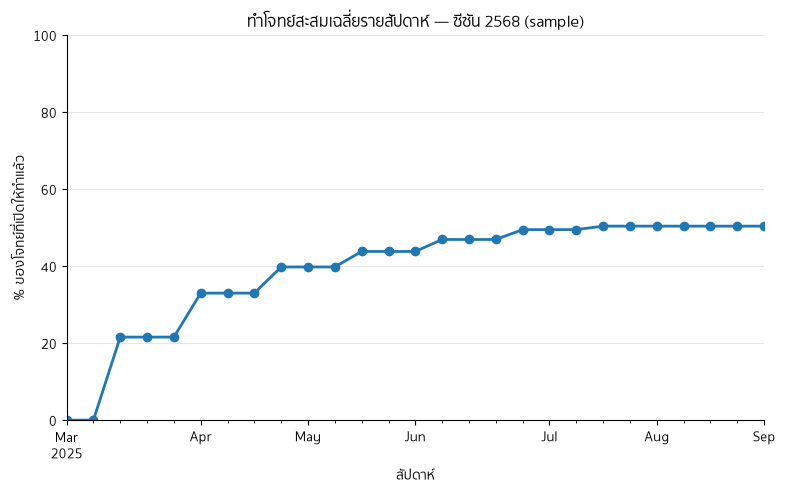

In [13]:
# ตัวอย่าง (เคสคู่ขนาน): ความคืบหน้าการทำโจทย์ (practice_pct) รายสัปดาห์ ซีซัน 2568
wm = pd.read_csv(DATA_DIR / "weekly_metrics.csv", parse_dates=["week_start", "week_end"])
wm68 = wm[wm["year"] == 2568]

practice_by_week = wm68.groupby("week_start")["practice_pct"].mean()

ax = practice_by_week.plot(marker="o", linewidth=2)
ax.set_title("ทำโจทย์สะสมเฉลี่ยรายสัปดาห์ — ซีซัน 2568 (sample)")
ax.set_xlabel("สัปดาห์")
ax.set_ylabel("% ของโจทย์ที่เปิดให้ทำแล้ว")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
plt.show()

# วิธีอ่าน: เส้นไต่ขึ้นเรื่อยๆ จาก 0 ต้นซีซันไปราวๆ 50% ปลายซีซัน
# = เด็กทำโจทย์ตามหลังโจทย์ที่ปล่อยออกมาประมาณครึ่งหนึ่ง — ใครต่ำกว่าเส้นนี้มากๆ คือน่าห่วง

### [แบบฝึกหัด 0.3] quick win: ชีพจรซีซันปัจจุบัน (2569)

วาดเส้น % เข้าเรียนเฉลี่ยรายสัปดาห์ของซีซันที่กำลังสอนอยู่:

1. กรอง `wm` เอาเฉพาะ `year == 2569` เก็บใน `wm69`
2. หาค่าเฉลี่ย `att_week_pct` ต่อ `week_start` เก็บใน `weekly_avg` (ต้องได้ Series)
3. plot กราฟเส้น ใส่ `marker="o"` + ตั้งชื่อกราฟ/แกนเป็นภาษาไทยได้เลย
   (font ไทยตั้งไว้ให้แล้วใน `plot_style()`)

**ผลที่คาด:** เส้น 22 จุด (มี.ค.–ก.ค. 2569) แกว่งอยู่แถวๆ 72–80% —
อ่านออกไหมครับว่าสัปดาห์ไหนเข้าเรียนแผ่วสุด? 😉

In [14]:
wm = pd.read_csv(DATA_DIR / "weekly_metrics.csv", parse_dates=["week_start", "week_end"])

____ = None  # กันเซลล์รันพัง — เติมช่องว่างด้านล่างให้ครบ

# TODO: กรองเฉพาะปี 2569
wm69 = ____

# TODO: ค่าเฉลี่ย att_week_pct ต่อ week_start (ผลลัพธ์เป็น Series)
weekly_avg = ____

# TODO: plot เมื่อ weekly_avg พร้อมแล้ว — เติมโค้ดในบล็อก if ข้างล่าง
if weekly_avg is not None:
    ax = weekly_avg.plot(marker="o", linewidth=2)
    # TODO: ตั้งชื่อกราฟ + แกน x/y (ax.set_title / ax.set_xlabel / ax.set_ylabel)
    ax.set_ylim(0, 100)           # แกนเริ่มที่ 0 เสมอ — ไม่หลอกตา
    ax.grid(axis="y", alpha=0.3)
    plt.show()

checks.check("ex_00_03", weekly_avg)

✗ ยังไม่ผ่าน: `weekly_avg` ยังเป็น None อยู่ — เติมช่องว่าง ____ ก่อนนะครับ


False

<details><summary>คำใบ้ 1 (แนวทาง)</summary>

โครงเดียวกับตัวอย่างกราฟทำโจทย์สะสมเป๊ะ — เปลี่ยนปีเป็นซีซันปัจจุบัน
และเปลี่ยนคอลัมน์ที่เอามาเฉลี่ยเป็นเปอร์เซ็นต์การเข้าเรียนรายสัปดาห์
</details>

<details><summary>คำใบ้ 2 (function ที่ใช้)</summary>

- กรองแถวด้วยเงื่อนไข `["year"] == 2569`
- `.groupby("week_start")["att_week_pct"].mean()`
- ตั้งชื่อกราฟ/แกน: `.set_title(...)` · `.set_xlabel(...)` · `.set_ylabel(...)`
</details>

In [15]:
# ถ้าอยากดูเฉลย: ลบ # หน้าบรรทัดล่าง แล้วรัน cell นี้ 2 ครั้ง (ครั้งแรก load, ครั้งสองรัน)
# %load ../solutions/sol_00_03.py

## สรุปสิ่งที่ได้จากบทนี้

- เปิดเครื่องมือเองได้แล้ว: venv → jupyter → รันทีละ cell + รู้จักโหมด SAMPLE/REAL
- รู้จักข้อมูลทั้ง 3 แหล่ง และเห็นกับตาว่า sample กับของจริงหน้าตาเดียวกัน
- ได้ท่า pandas ที่จะใช้ทั้งหลักสูตร: `read_csv` + `parse_dates` · `nunique` ·
  filtering ด้วย `year` · `sort_values → groupby → last` · `groupby → mean → plot`
- ตอบคำถามธุรกิจจริงไป 3 ข้อ และวาดกราฟชีพจรซีซัน 2569 ด้วยมือตัวเอง

**บทต่อไป (01):** คำถามที่ฟังดูง่ายแต่ลึกมาก — *"ตกลงนับยังไงว่าเด็กคนหนึ่ง churn?"*
ลดวิชานับไหม? ออกเดือน ก.ย. ตอนจบซีซันนับไหม? นิยามพลาดนิดเดียว โมเดลเก่งแค่ไหนก็ช่วยไม่ได้
— เจอกันบทหน้าครับ 💚